In [ ]:
%matplotlib ipympl
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

In [ ]:
from raytracer_2d import (
    get_rect_subdivs,
    get_rects_center_2d,
    get_rects_verts_2d,
    get_fov_pixel_centers_2d,
    get_rays_2d,
    get_fov_verts_2d,
    get_convex_hull_2d,
    get_furthest_corners,
    if_rects_in_hull_2d,
    if_rects_intersect_hull_2d,
    
)

from raytracer_2d import plot_rects, plot_scanner_2d

In [80]:
# define the subdivisions of the crystal
rect = torch.tensor(
    [[32, 4], [8, 0], [0, 8]],
    dtype=torch.float32,
)
xtal_nsubs = torch.tensor([9, 9])

rect_subs = get_rect_subdivs(rect, xtal_nsubs)
plate_rects = torch.tensor(
    [
        [[29, 8], [2, 0], [0, 8]],
        [[29, -2], [2, 0], [0, 8]],
    ],
    dtype=torch.float32,
)
# define the field of view (FOV)
fov_npx = torch.tensor([4, 4])
fov_mmppx = torch.tensor([8, 8])
fov_dims = fov_npx * fov_mmppx

# get the points a and b for the rays
pa_tensor = get_fov_pixel_centers_2d(fov_npx, fov_mmppx)
pb_tensor = get_rects_center_2d(rect_subs)
rays = get_rays_2d(pa_tensor.view(-1, 2), pb_tensor.view(-1, 2))

fov_verts = get_fov_verts_2d(fov_dims)
pixel_corners = get_furthest_corners(pa_tensor.view(-1, 2), 4)

insid_indices = []
intsc_indices = []
hulls = []
i_list = torch.arange(rect_subs.shape[0])
candidates = torch.vstack((plate_rects, rect_subs))
candidates_verts = get_rects_verts_2d(candidates)
for i in i_list:

    hull = get_convex_hull_2d(torch.vstack((pb_tensor[i], pixel_corners)))
    local_intsc_indices = if_rects_intersect_hull_2d(
        candidates, hull, pb_tensor[i]
    )
    local_intsc_indices = local_intsc_indices[~local_intsc_indices.eq(i)]
    intsc_indices.append(local_intsc_indices.tolist())
    insid_indices.append(
        torch.argwhere(if_rects_in_hull_2d(candidates, hull)).squeeze().tolist()
    )
    hulls.append(hull)
    # print(insid_indices.shape, valid_indices.shape)

focused_rects_p tensor([[32.0000,  4.0000],
        [32.8889,  4.0000],
        [32.8889,  4.8889],
        [32.0000,  4.8889]])


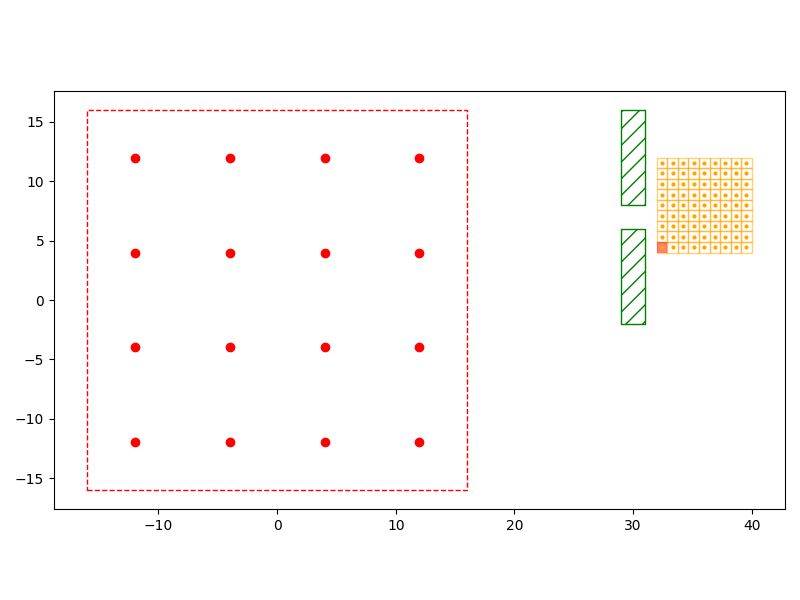

In [81]:
rects_verts = get_rects_verts_2d(candidates)
try:
    plt.close()
except Exception as e:
    pass

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
ax.set_aspect("equal")
pstyles = [
    {"fc": "none", "ec": "green", "hatch": "//", "label": "Plate"},
    {"fc": "none", "ec": "orange", "alpha": 0.5, "label": "Subdivisions"},
]
plot_scanner_2d(ax, [plate_rects, rect_subs], rays, pstyles)
plate_rects_pcoll = plot_rects(plate_rects, ax, visible=False)
xtal_rects_pcoll = plot_rects(rect_subs, ax, visible=False)

idx = 0
rects_inter = candidates[:1]
rects_insid = candidates[:1]
rects_inter_pcoll = plot_rects(
    rects_inter, ax, fc="blue", alpha=0.5, visible=False
)
rects_insid_pcoll = plot_rects(
    rects_insid, ax, fc="green", alpha=0.5, visible=False
)
focused_rects_polygon = Polygon(
    rects_versts[2], closed=True, fc="r", ec="none", alpha=0.5
)
ax.add_patch(focused_rects_polygon)
print("focused_rects_p", rects_versts[2])

hull_poly = Polygon(
    hulls[0],
    closed=True,
    fill=None,
    edgecolor="green",
    linestyle="--",
    linewidth=1,
    visible=False,
)
ax.add_patch(hull_poly)

ax.add_patch(
    Polygon(
        fov_verts,
        closed=True,
        fill=None,
        edgecolor="r",
        linestyle="--",
        linewidth=1,
    )
)
ax.plot(pa_tensor.view(-1, 2)[:, 0], pa_tensor.view(-1, 2)[:, 1], "o", c="r")
text_obj = ax.text(0.9, 0.99, "", transform=ax.transAxes, ha="center", va="top")


def reset_visibility():
    focused_rects_polygon.set_visible(False)
    rects_inter_pcoll.set_visible(False)
    rects_insid_pcoll.set_visible(False)
    hull_poly.set_visible(False)
    text_obj.set_text("")
    fig.canvas.draw_idle()


def on_move(event):
    if event.inaxes:
        for idx, patch in enumerate(xtal_rects_pcoll.get_paths()):
            if patch.contains_point((event.xdata, event.ydata)):

                try:
                    text_obj.set_text(f"Polygon ID: {idx}")
                    inside_verts = rects_verts[insid_indices[idx]]
                    inside_verts = (
                        inside_verts.unsqueeze(0)
                        if inside_verts.dim() == 2
                        else inside_verts
                    )
                    rects_insid_pcoll.set_verts(inside_verts)
                    rects_insid_pcoll.set_visible(True)
                    hull_poly.set_xy(hulls[idx])
                    hull_poly.set_visible(True)

                    focused_rects_polygon.set_visible(True)
                    focused_rects_polygon.set_xy(rects_versts[idx + 2])
                    rects_inter_pcoll.set_verts(rects_verts[intsc_indices[idx]])
                    rects_inter_pcoll.set_visible(True)
                except Exception as e:
                    print(e)
                fig.canvas.draw_idle()
                break
            else:
                reset_visibility()
    else:
        reset_visibility()
    fig.canvas.draw_idle()


fig.canvas.mpl_connect("motion_notify_event", on_move)


plt.tight_layout()
plt.show()

In [83]:
print(insid_indices[1])

[]


In [76]:
for id in [34, 35]:
    print(rects_verts[insid_indices[id]])

tensor([[32.0000,  9.3333],
        [32.8889,  9.3333],
        [32.8889, 10.2222],
        [32.0000, 10.2222]])
tensor([[[32.0000,  9.3333],
         [32.8889,  9.3333],
         [32.8889, 10.2222],
         [32.0000, 10.2222]],

        [[32.0000, 10.2222],
         [32.8889, 10.2222],
         [32.8889, 11.1111],
         [32.0000, 11.1111]],

        [[32.8889, 10.2222],
         [33.7778, 10.2222],
         [33.7778, 11.1111],
         [32.8889, 11.1111]]])
